C:\Users\tspro\AppData\Local\Temp\ipykernel_7252\4081157820.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("Pantheon_SH0ES.dat", delim_whitespace=True)


Text(0.5, 0, 'Logarithmic Redshift')

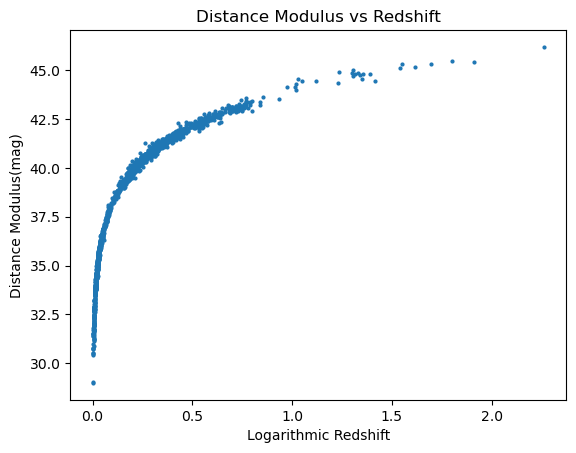

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
data = pd.read_csv("Pantheon_SH0ES.dat", delim_whitespace=True)


z = data["zHD"]

d = data["MU_SH0ES"]
sigma = data["MU_SH0ES_ERR_DIAG"]

plt.scatter(z,d, s = 4)
plt.title("Distance Modulus vs Redshift")
plt.ylabel("Distance Modulus(mag)")
plt.xlabel("Logarithmic Redshift")


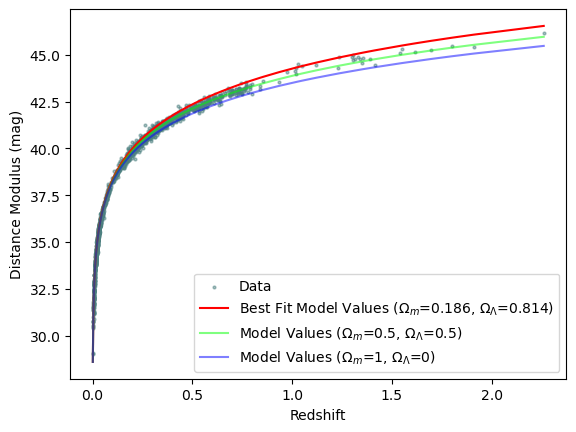

In [37]:
c = 3e5
H_0 = 70

omega_m = 0.186
omega_lambda = 0.814

omega_m1 = 0.5
omega_lambda1 = 0.5

omega_m2 = 1
omega_lambda2 = 0

def H(h): #using h as dummy variable for z
    return H_0*np.sqrt(omega_m*(1+h)**3+omega_lambda)

def d_L(h):
    integral, _ = quad(lambda h: 1.0 / H(h), 0, h)
    return (1 + h) * c * integral #returns in Mpc


def d_model(h):
    return 5 * np.log10(d_L(h)) + 25
dL_vals = np.array([d_model(h) for h in z])



def H1(h): #using h as dummy variable for z
    return H_0*np.sqrt(omega_m1*(1+h)**3+omega_lambda1)

def d_L1(h):
    integral, _ = quad(lambda h: 1.0 / H1(h), 0, h)
    return (1 + h) * c * integral #returns in Mpc


def d_model1(h):
    return 5 * np.log10(d_L1(h)) + 25
dL_vals1 = np.array([d_model1(h) for h in z])

def H2(h): #using h as dummy variable for z
    return H_0*np.sqrt(omega_m2*(1+h)**3+omega_lambda2)

def d_L2(h):
    integral, _ = quad(lambda h: 1.0 / H2(h), 0, h)
    return (1 + h) * c * integral #returns in Mpc


def d_model2(h):
    return 5 * np.log10(d_L2(h)) + 25
dL_vals2 = np.array([d_model2(h) for h in z])

plt.scatter(z,d, color = (0.3, .5,.5,.5), label = "Data", s = 4)
plt.plot(z, dL_vals, color=(1, 0, 0), label=f"Best Fit Model Values ($\\Omega_m$={omega_m}, $\\Omega_\\Lambda$={omega_lambda})")
plt.plot(z, dL_vals1, color = (0,1,0,.5), label=f"Model Values ($\\Omega_m$={omega_m1}, $\\Omega_\\Lambda$={omega_lambda1})")
plt.plot(z, dL_vals2, color = (0,0,1,.5), label=f"Model Values ($\\Omega_m$={omega_m2}, $\\Omega_\\Lambda$={omega_lambda2})")


plt.xlabel("Redshift")
plt.ylabel("Distance Modulus (mag)")
plt.legend()
plt.show()


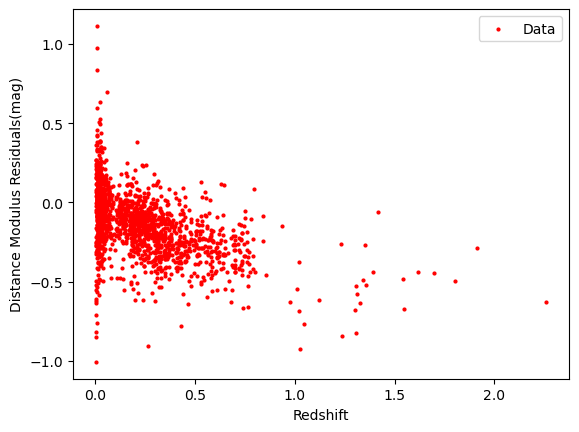

In [43]:

res = dL_vals - d
plt.scatter(z,res, color = 'red', label = "Data", s = 4)

plt.xlabel("Redshift")
plt.ylabel("Distance Modulus Residuals(mag)")
plt.legend()
plt.show()


In [19]:
#for loop for chi^2
romega_m = np.linspace(0,1,1000)
intvals = np.linspace(0,999,1000, dtype=int)
omega_m = 0

chi2vals = []
for i in intvals:
    

        
    omega_lambda = 1- romega_m[i]
    def H(h, omega_m): #using h as dummy variable for z
        return H_0*np.sqrt(omega_m*(1+h)**3+omega_lambda)

    def d_L(h, omega_m):
        integral, _ = quad(lambda h: 1.0 / H(h, omega_m), 0, h)
        return (1 + h) * c * integral #returns in Mpc
    

    def d_model(h, omega_m):
        return 5 * np.log10(d_L(h, omega_m)) + 25
    dL_vals = np.array([d_model(h, omega_m) for h in z])
        
    redchi2 = (np.sum(((d-dL_vals)/ sigma)**2))/1699
    chi2vals.append(redchi2)

    omega_m = omega_m + 0.001






In [20]:

good_omega = []
for i in intvals:
    if chi2vals[i] > 0.998 and chi2vals[i] < 1.002:
        good_omega.append(romega_m[i])    
print(good_omega)

[np.float64(0.18618618618618618)]


0.5173847369611776


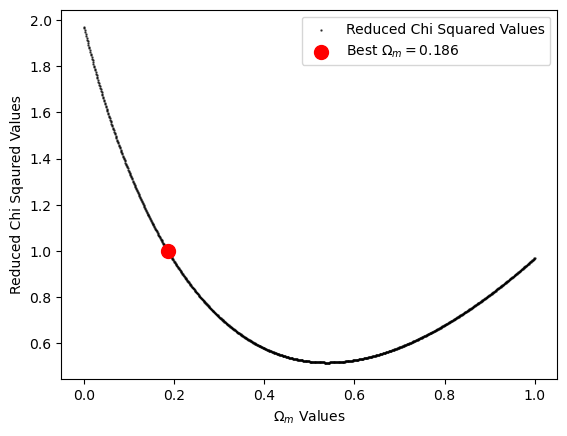

In [36]:
#reduced chi vs omega_m

plt.scatter(romega_m, chi2vals, color = (0,0,0, 0.7), label ='Reduced Chi Squared Values', s=0.5)
plt.scatter(0.186, 1, color='red', s=100, marker='o', zorder=5, label=r'Best $\Omega_m = 0.186$')


minn = np.min(chi2vals)
print(minn)
plt.xlabel(r'$\Omega_m$ Values')
plt.ylabel(r'Reduced Chi Sqaured Values')
plt.legend()
plt.show()





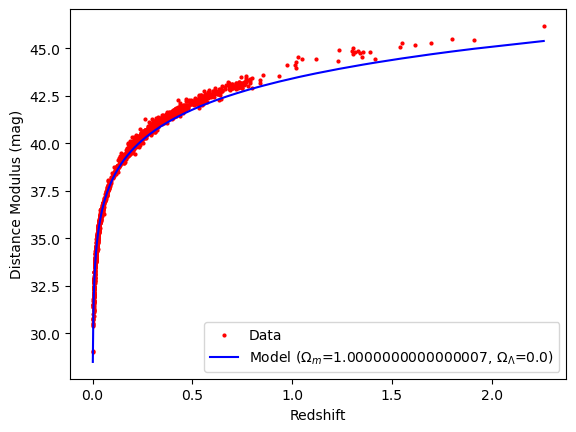

In [48]:
plt.scatter(z,d, color = 'red', label = "Data", s = 4)
plt.plot(z, dL_vals, color = 'blue', label=f"Model ($\\Omega_m$={omega_m}, $\\Omega_\\Lambda$={omega_lambda})")
plt.xlabel("Redshift")
plt.ylabel("Distance Modulus (mag)")
plt.legend()

plt.show()

